## Replication of Section 5.3 (Gaussian mutations)

The results produced by Basener's [Realistic Mutation-Selection Modeling](https://people.rit.edu/wfbsma/evolutionary%20dynamics/EvolutionaryModel.html) webpage for the `Gaussian` option are nowhere close to those reported in Section 5.3. Basener and Sanford indicate that the standard deviation of the (zero-mean) distribution of probabilty over mutation effects is 0.002, but the parameter is presently set to 0.0005 in the JavaScript. Hence I have changed the standard deviation from 0.0005 to 0.002 in [BS.js](../Code/BS.js), the excerpt of Basener's code that we use to check the results reported in the article.

```javascript
function mutationProb(mDiff, mDelta, mt) {
    if (mt == "Gaussian") {
        var stdevMutation = /* 0.0005 */ 0.002;  // as reported
        GaussianMultiplicativeTerm = 1 / (stdevMutation * Math.sqrt(2 * Math.PI));
        f = GaussianMultiplicativeTerm * Math.exp(-0.5 * Math.pow((mDiff) / stdevMutation, 2));
        f = f * mDelta;
    }
    // Other cases of mutation type `mt` intervene.
    return f;
}
```

The function returns the probability that, when a single mutation occurs in an offpring, the difference in fitness of the type of the offspring and the type of the parent is `mDiff`.

The function returns the probability that mutation results in a difference of `mDiff` in the types of an offspring and its parent. 

mutation results in a difference `mDiff` in the fitnesses of the type of an offspring from the type of its parent. To approximate the probability mass for the subinterval of length `mDelta` centered on the fitness difference `mDiff`, Basener

1. calculates the probability density at the center of the subinterval, and
2. multiplies the density by the length of the subinterval.

First the probability density at `mDiff`, a possible difference in fitness (Malthusian growth factor) of the type of an offspring from the type of its parent, is calculated. The variable `mDelta` is the width of the fitness "bins" into which the fitness interval is divided. What Basener does is to calculate the probability density at the center of the bin, and then to multiply by the width of the bin. 

We load the output of Basener's code, and verify that the "population size" was set to finite.

In [29]:
%matplotlib notebook
%run ../Code/bs.py

In [30]:
with gzip.open('../Basener_Sanford_Data/bs5_3.pickled.gz', 'rb') as f:
    data = pickle.load(f)
original = WrappedBS(data, 'original')
n_years = len(original) - 1
n_types = len(original[0])
data['PopSize']

'Finite'

The significance of the `Finite` setting of `PopSize` is that the frequency distribution is thresholded in each generation. That is, frequencies less that 1e-9 times the maximum frequency are set to zero. In their article, Basener and Sanford claim that the threshold is 1e-9 times the size of the population (the sum of the frequencies). But Basener's JavaScript tells a different story.

CODE HERE

In the following cell, the `BS_Population` uses the `max` function in thresholding, and excludes the upper endpoint of the interval of growth factors, as does Basener's code.

In [33]:
mutations = GaussianEffects(n_types+1, std=0.002, approximate=True, normed=False)
assert mutations.delta == data['mDelta']
maximum_absolute_relative_error(mutations[1:-1], data['mutation_probs'])

3.3306690738754696e-16

In [34]:
init = GaussianFactors(n_types+1, mean=0.044, std=0.005, crop=11.2, approximate=True)
maximum_absolute_relative_error(init[:-1], original[0])

2.220446049250313e-16

In [35]:
max_pop = BS_Population(init, mutations, threshold_norm=np.max, endpoint=False, label='replicate')
replicate = Evolution(max_pop, n_years=n_years)
maximum_absolute_relative_error(replicate[:, :-1], original)

8.770761894538737e-14

<IPython.core.display.Javascript object>


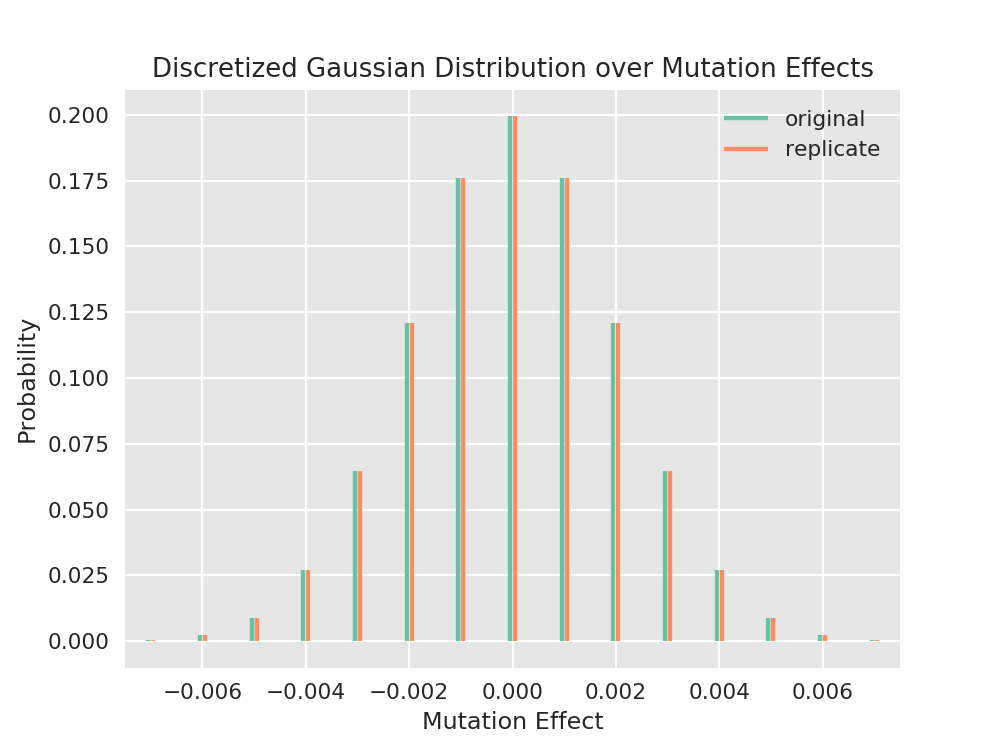

In [16]:
fig, ax = plt.subplots()
ax.set_title('Discretized Gaussian Distribution over Mutation Effects')
ax.set_xlabel('Mutation Effect')
ax.set_ylabel('Probability')
ax.set_xlim(-0.0075, 0.0075)
offset = 0.00005
v = ax.vlines(mutations.domain[1:-1] - offset, 0, data['mutation_probs'], label='original')
v.set_color(sns.color_palette()[0])
v = mutations.vlines(ax, offset, 'replicate')
v.set_color(sns.color_palette()[1])
ax.legend();

I mention now a point that I will emphasize in ???: Basener and Sanford do not plot the distributions that they actually use in the annual update of frequencies. It is easy to see, in their [Figure 1](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig1_HTML.gif), that they have sliced the interval of mutation effects much more finely than they do in the computation. It is in fact important to know the percentage of mutations that have no effect on the fitness of the offspring. 

**Move to the other notebook**

The following figure reveals what Basener and Sanford have concealed. It's not a pretty picture.

<IPython.core.display.Javascript object>


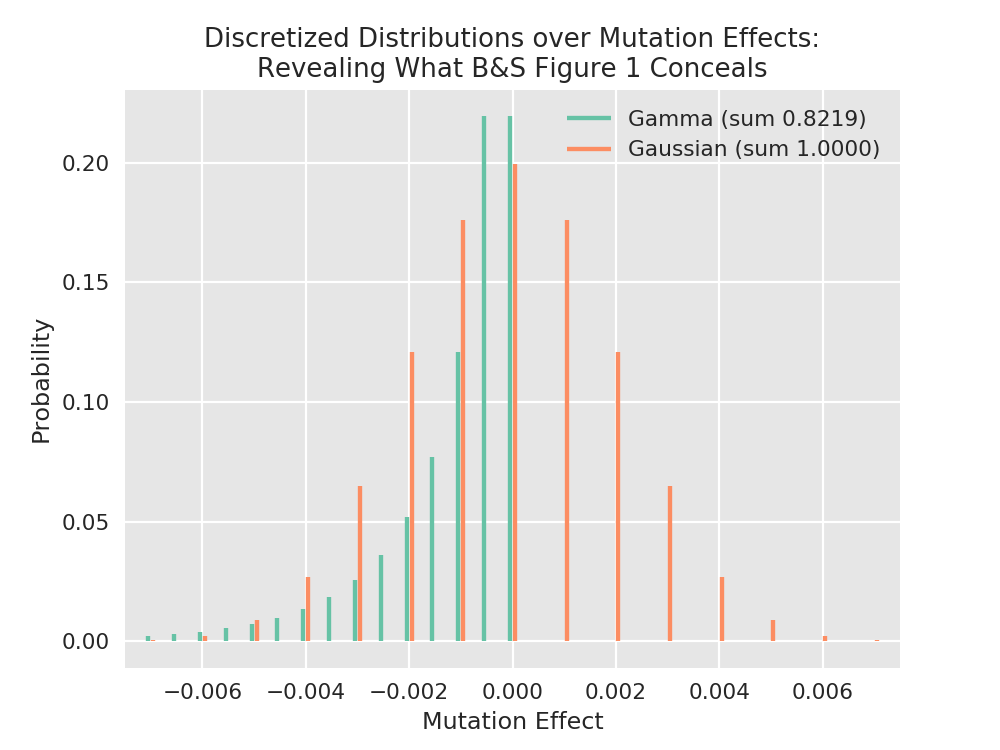

In [15]:
gamma = GammaEffects(2*n_types+1, approximate=True, gimmick=True, percent_beneficial=0.001, normed=False)
fig, ax = plt.subplots()
title = 'Discretized Distributions over Mutation Effects'
subtitle = ':\nRevealing What B&S Figure 1 Conceals'
ax.set_title(title + subtitle)
ax.set_xlabel('Mutation Effect')
ax.set_ylabel('Probability')
ax.set_xlim(-0.0075, 0.0075)
v = gamma.vlines(ax, -offset, label='Gamma (sum {0:.4f})'.format(gamma.norm()))
v.set_color(sns.color_palette()[0])
v = mutations.vlines(ax, offset, 'Gaussian (sum {0:.4f})'.format(mutations.norm()))
v.set_color(sns.color_palette()[1])
ax.legend();

In [ ]:
mutations.normalize()
mutations.norm(), mutations.mean_and_variance()

In [ ]:
init = GaussianRates(n_types+1, mean=0.044, std=0.005, crop=11.2, approximate=True)
pop = BS_Population(init, mutations, threshold_norm=np.max, endpoint=False, label='max')
our_max = Evolution(pop, n_years)
n=300
max_relative_error(bs_max, our_max[:, :-1]), np.max(np.abs(bs_max - our_max[:, :-1]))

In [ ]:
pop = BS_Population(init, mutations, threshold_norm=np.sum, endpoint=False, label='sum')
size = Evolution(pop, n_years)
pop = BS_Population(init, mutations, threshold_norm=None, endpoint=False, label='zero')
zero = Evolution(pop, n_years)

In [ ]:
c = CompareProcesses([zero, bs_max, size], subtitle='\nComparison of Threshold Functions')
c.animate(nframes=11, duration=10000)

This suggests that we might observe a difference in mean fitness at year 150, and thus confirm that Basener and Sanford used `min`, and not `sum`, to generate their data.

In [ ]:
(mean_and_variance(inaccurate.normalized()[150], inaccurate.growth_rates()),
mean_and_variance(more_inaccurate.normalized()[150], inaccurate.growth_rates()))

Can we be sure that Basener and Sanford report the results of thresholding relative to the maximum of the frequencies, and not relative to the sum of the frequencies? Perhaps Basener has changed the function used in thresholding the frequency distribution, just as he has changed the standard deviation of the distribution over mutation effects. There are only 300 iterations in the run:

In [ ]:
n_years

**Note somewhere** Interestingly, Basener's code presently sets the standard deviation of the mutation effects considerably smaller (**value**). The consequence is that the mean fitness does not increase as rapidly as it is shown to increase in the article. It just happens that Basener and Sanford emphasize how rapidly the fitness increases, and attribute the effect to zero-mean fitness effects, without giving an account of how they chose the standard deviation. The standard deviation in the Gamma case (Section 5.4) is much smaller. The very fact that Basener and Sanford have used this tactic tells us that we need to increase the dispersion in the Gamma case, and see what happens. **What happens when we increase the dispersion in the Gamma case?**

In [ ]:
pop = BS_Population(init, mutations, threshold_norm=np.max)
pop._freqs[-1] = 0
result = np.empty(gaussian[:].shape)
result[0] = pop[:-1]
for i in range(1, n_years+1):
    pop.annual_update()
    pop._freqs[-1] = 0
    result[i] = pop[:-1]
np.allclose(result, gaussian)

In [ ]:
accurate = Evolution(BS_Population(init, mutations, threshold_norm=np.max), n_years)
np.allclose(gaussian, inaccurate[:, :-1])

In [ ]:
inaccurate[-1, -1]

In [ ]:
gaussian[n]